**Hi** folks,

Today I am working on **Multiple linear regression** which is same like our **Simple linear regression**,but the only difference is....in **Simple linear regression** we work only with one dependent and one independent variable,but in Multiple linear regression we can work more than one dependent variable and independent variable. Apart from this we follow same steps as simple linear regression.

**About this Dataset**

This dataset has data collected from New York, California and Florida about 50 business Startups "17 in each state". The variables used in the dataset are Profit, R&D spending, Administration Spending, and Marketing Spending.

It's a great dataset for evaluating Multiple regression models.

**Goal:-**
To predict whether a particular startup would be **safe to invest in or not**.

**step1 #Data preprocessing**

In [68]:
# importing libraray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
df=pd.read_csv("50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


Dataset contain 5 columns--**"R&D Spend"**,**"Administration"**,**"Marketing Spend"**,**"State"**,**"Profit"**.
1. **R&D** Spend Research and development – R&D – is the process by which a company works to obtain new knowledge that it might use to create new technology, products, services, or systems that it will either use or sell. So,this column tells you how much you spend on R&D.

2. **Administration** It is the process of arrangements and tasks needed to control the operation of a plan or organization.

3. **Marketing Spend** refers to activities undertaken by a company to promote the buying or selling of a product or service. Marketing includes advertising, selling, and delivering products to consumers or other businesses.

4. **State** This column contain three states which is Califonia,Newyork and Floida

5. **profit** is a financial benefit that is realized when the amount of revenue gained from a business activity exceeds the expenses, costs, and taxes needed to sustain the activity.

In [70]:
df.isnull().sum()  # this will show us the null values in the dataset

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [72]:
df["State"].unique()  # this will show us the unique values in the state column

array(['New York', 'California', 'Florida'], dtype=object)

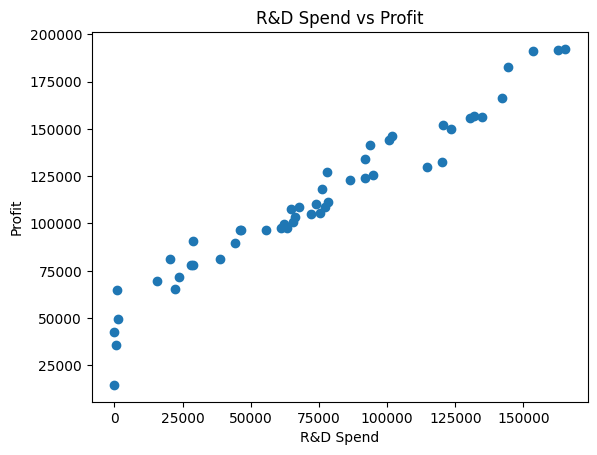

In [73]:
# lets analyze by scatter plot
x1=df.iloc[:,0].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("R&D Spend vs Profit")
plt.show()

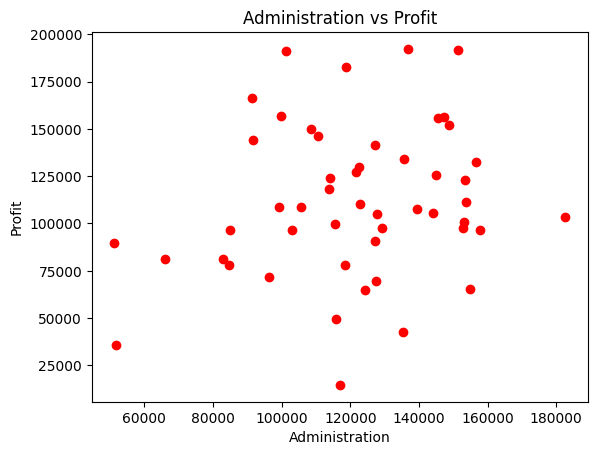

In [74]:
x1=df.iloc[:,1].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1,color="red")
plt.xlabel("Administration")
plt.ylabel("Profit")
plt.title("Administration vs Profit")
plt.show()

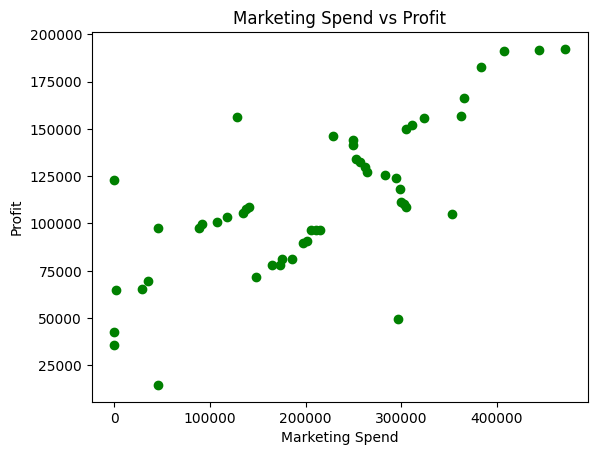

In [75]:
x1=df.iloc[:,2].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1,color="green")
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")
plt.show()

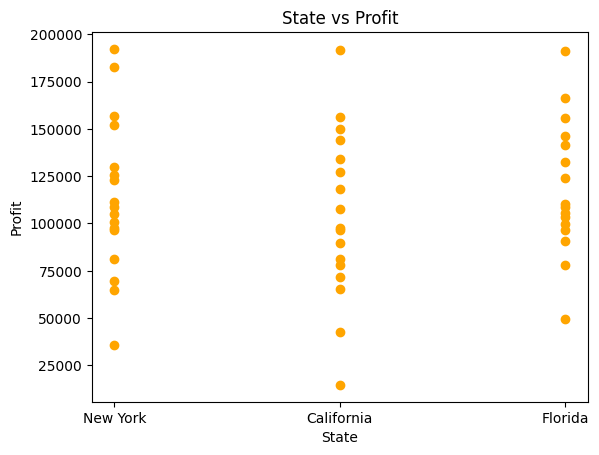

In [76]:
x1=df.iloc[:,3].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1,color="orange")
plt.xlabel("State")
plt.ylabel("Profit")
plt.title("State vs Profit")
plt.show()

In [77]:
X=df.iloc[:,:-1].values
y=df.iloc[:,4].values
print(X)
print(y)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [3])
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)

In [79]:
X = X[:, 1:]

In [80]:
print(X)

[[0.0 1.0 165349.2 136897.8 471784.1]
 [0.0 0.0 162597.7 151377.59 443898.53]
 [1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 1.0 131876.9 99814.71 362861.36]
 [0.0 0.0 134615.46 147198.87 127716.82]
 [1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 1.0 120542.52 148718.95 311613.29]
 [0.0 0.0 123334.88 108679.17 304981.62]
 [1.0 0.0 101913.08 110594.11 229160.95]
 [0.0 0.0 100671.96 91790.61 249744.55]
 [1.0 0.0 93863.75 127320.38 249839.44]
 [0.0 0.0 91992.39 135495.07 252664.93]
 [1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 1.0 114523.61 122616.84 261776.23]
 [0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 1.0 94657.16 145077.58 282574.31]
 [1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 1.0 86419.7 153514.11 0.0]
 [0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 1.0 78389.47 153773.43 299737.29]
 [1.0 0.0 73994.56 122782.75 303319.26]
 [1.0 0.0 67532.53 105751.03 304768.73]
 [0.0 1.0 77044.01 99281.34 140574.81]
 [0

# building Model

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
Mlr=LinearRegression()
Mlr.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
y_pred=Mlr.predict(x_test)

In [83]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.93470684732824


In [84]:
y_diff=y_test-y_pred
print(y_diff)

[   267.17840203  11677.12239185  13674.21154825   5822.73148742
  12512.90778946 -11152.93230164  13377.36790324  -1308.17374688
  -3617.18533012  -1733.1256955 ]


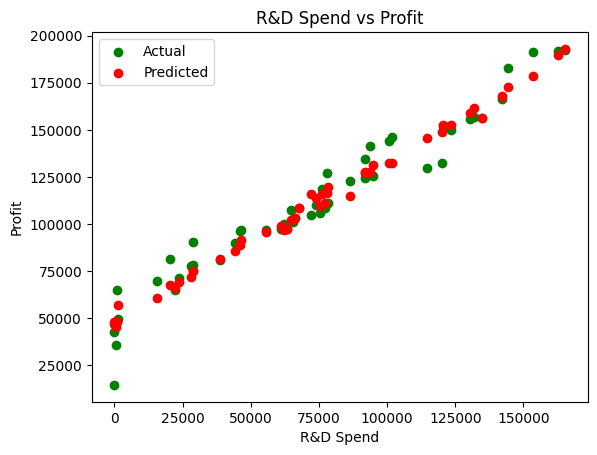

In [85]:
# lets analyze by scatter plot
x1=df.iloc[:,0].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1,label="Actual",color="green")
plt.scatter(x1,Mlr.predict(X),label="Predicted",color="red")
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("R&D Spend vs Profit")
plt.legend()
plt.show()

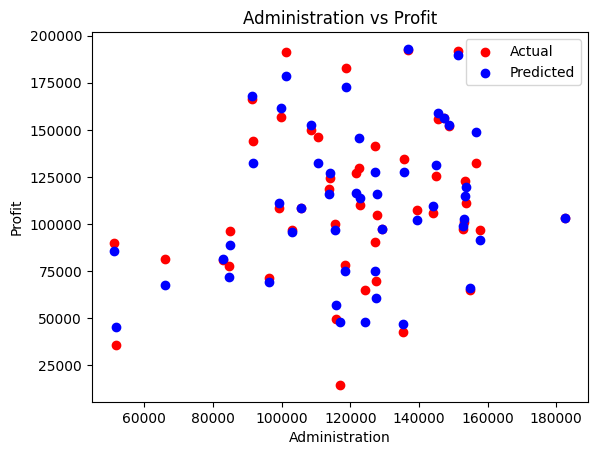

In [86]:
x1=df.iloc[:,1].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1,color="red",label="Actual")
plt.scatter(x1,Mlr.predict(X),label="Predicted",color="blue")
plt.xlabel("Administration")
plt.ylabel("Profit")
plt.title("Administration vs Profit")
plt.legend()
plt.show()

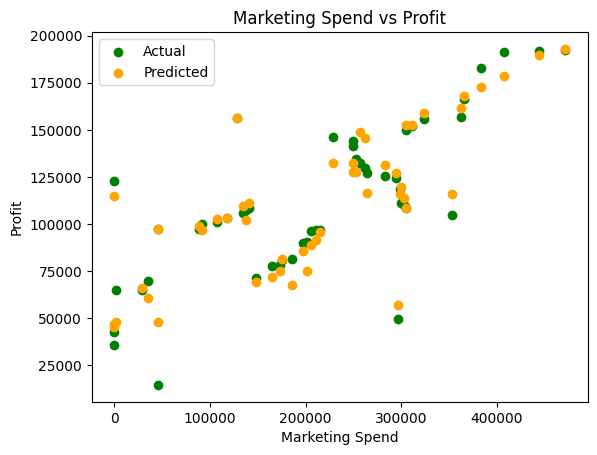

In [87]:
x1=df.iloc[:,2].values
y1=df.iloc[:,4].values
plt.scatter(x1,y1,color="green",label="Actual")
plt.scatter(x1,Mlr.predict(X),label="Predicted",color="orange")
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")
plt.legend()
plt.show()

These graph shows that how the predicted value chase the actual value it shows the how accurate our prediction is

# Making our own Multiple regression class

In [88]:
class Mylr:
    def __init__(self):
        self.coefficients = None
        self.intercept = None
    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)

        # calculate the coefficients and intercept
        beta=np.linalg.inv(x_train.T.dot(x_train)).dot(x_train.T).dot(y_train)
        self.intercept = beta[0]
        self.coefficients=beta[1:]
    def predict(self,x_test):
        y_pred=self.intercept + np.dot(x_test,self.coefficients)
        return y_pred